In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
exp = pd.read_csv("results/experiments.csv")
exp = exp[pd.isna(exp["scheduler"])]
cur = pd.read_csv("results/curves.csv")
cur = cur[cur["epoch"] <= 15]
df = cur.loc[cur.groupby("timestamp")["val_acc"].idxmax(), 
                 ["timestamp", "val_loss", "val_acc"]]
df = df.merge(exp, on="timestamp", how="left")
idx = df.groupby("model")["val_acc"].idxmax()
df.loc[idx]

,timestamp,val_loss,val_acc,model,pretrained_weights,optimizer,learning_rate,batch_size,num_epochs,weight_decay,dropout,scheduler,data_augmentation,best_val_acc,training_time_s
22,1774282694,0.456075,0.867086,densenet121,IMAGENET1K_V1,SGD,0.001,32.0,15.0,0.0001,0.0,NaN,standard,0.867086,5120.51
40,1774642813,0.773329,0.725178,four_block,none,SGD,0.010,64.0,15.0,0.0001,0.0,NaN,standard,0.725178,2018.85
32,1774626072,1.291365,0.696288,ghostnetv3,IMAGENET1K_V1,SGD,0.001,32.0,15.0,0.0001,0.0,NaN,standard,0.696288,6542.37
4,1773956425,0.537382,0.830776,resnet18,IMAGENET1K_V1,SGD,0.001,32.0,40.0,0.0001,0.0,NaN,standard,0.837233,4560.68


In [4]:
exp = pd.read_csv("results/experiments.csv")
cur = pd.read_csv("results/curves.csv")
cur = cur[cur["epoch"] <= 15]
result = cur.loc[cur.groupby("timestamp")["val_loss"].idxmin(), 
                 ["timestamp", "val_loss", "val_acc"]]
result = result.rename(columns={
    "val_loss": "min_val_loss",
    "val_acc": "coresponding_val_acc"
})
exp = exp[pd.isna(exp["scheduler"])]
exp = exp.merge(result, on="timestamp", how="left")
exp = exp.drop(['best_val_acc'], axis=1)

In [5]:
idx = exp.groupby("model")["min_val_loss"].idxmin()
exp.loc[idx]

,timestamp,model,pretrained_weights,optimizer,learning_rate,batch_size,num_epochs,weight_decay,dropout,scheduler,data_augmentation,training_time_s,min_val_loss,coresponding_val_acc
8,1774282694,densenet121,IMAGENET1K_V1,SGD,0.001,32,15,0.0001,0.0,NaN,standard,5120.51,0.428635,0.859479
22,1774642813,four_block,none,SGD,0.010,64,15,0.0001,0.0,NaN,standard,2018.85,0.773329,0.725178
16,1774626225,ghostnetv3,IMAGENET1K_V1,SGD,0.010,32,15,0.0001,0.0,NaN,cutmix,6130.98,0.976123,0.682948
35,1773956425,resnet18,IMAGENET1K_V1,SGD,0.001,32,40,0.0001,0.0,NaN,standard,4560.68,0.517771,0.824956


In [6]:
# min loss on valid for each model
min_loss = cur.groupby("timestamp")[["epoch", "val_loss"]].agg("min")
# max acc on valid for each model
max_acc = cur.groupby("timestamp")["val_acc"].agg("max")

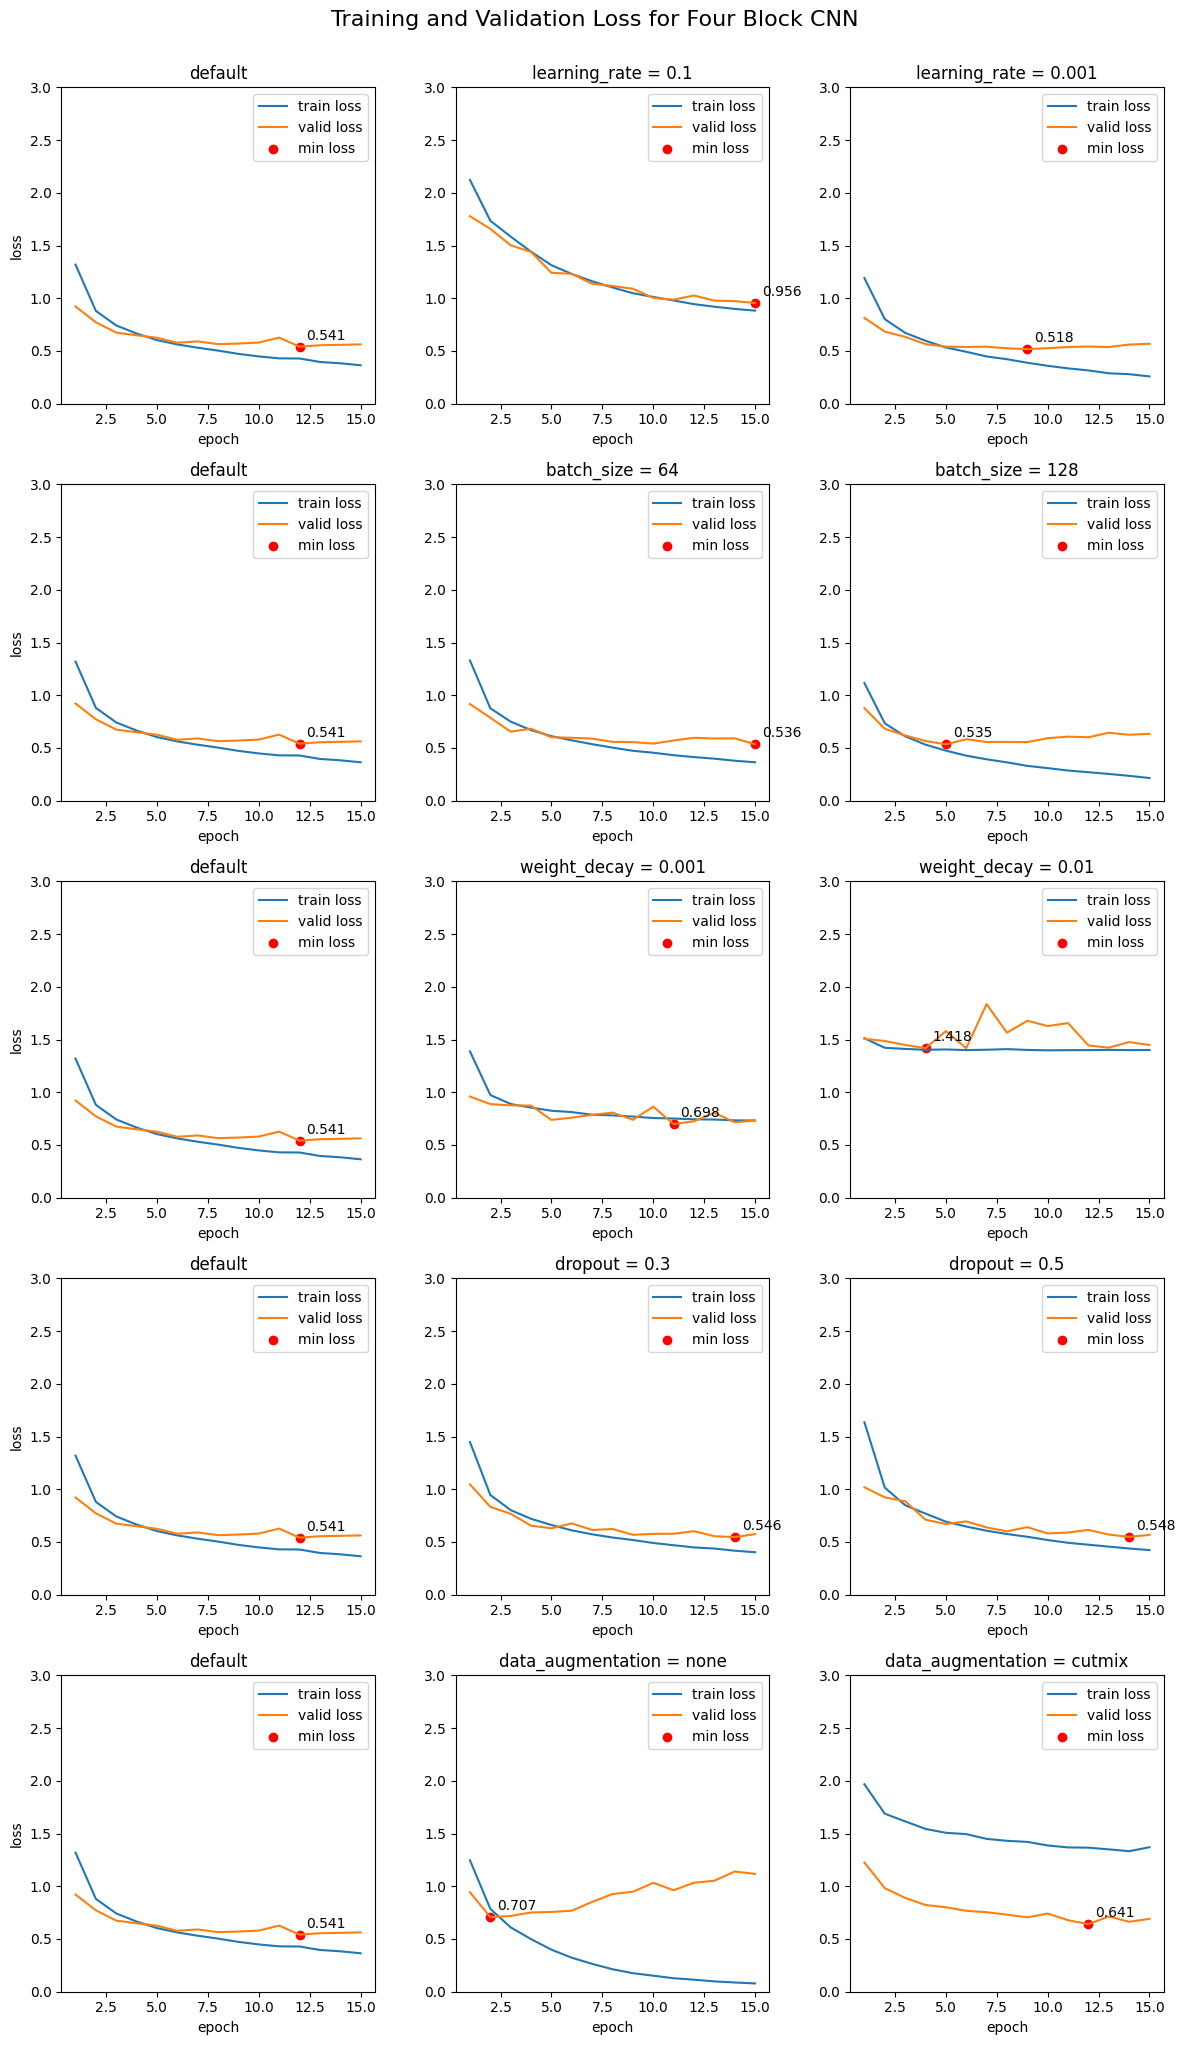

In [7]:
ts_default_four = 1774634170
ts_default_ghostnet = 1774290736
ts_default_resnet = 1773854727
ts_default_densenet = 1774088363

# zmienic nazwe modelu, na ktora chcemy plotowac: resnet18, ghostnetv3, densenet121, four_block
exp = exp[(exp["model"] == "resnet18") & (pd.isna(exp["scheduler"]))]
cur = cur[cur["epoch"] <= 15]
hyperparams = {
    "learning_rate": [0.1, 0.001],
    "batch_size": [64, 128],
    "weight_decay": [0.001, 0.01],
    "dropout": [0.3, 0.5],
    "data_augmentation": ["none", "cutmix"],
}
ts = []
for key, value in hyperparams.items():
    for v in value:
        ts.append(int(exp[exp[key] == v]["timestamp"].iloc[0]))

# zmienic timestamp
ts_default = ts_default_resnet

fig, axs = plt.subplots(5, 3, figsize=(12, 20))

i = 0
for key, value in hyperparams.items():
    cur_def = cur[cur["timestamp"] == ts_default]
    axs[i, 0].plot(cur_def["epoch"], cur_def["train_loss"], label="train loss")
    axs[i, 0].plot(cur_def["epoch"], cur_def["val_loss"], label="valid loss")
    min_def = cur_def.loc[cur_def["val_loss"].idxmin()]
    axs[i, 0].scatter(
        min_def["epoch"], min_def["val_loss"], color="red", label="min loss"
    )
    axs[i, 0].annotate(
        f'{min_def["val_loss"]:.3f}',
        (min_def["epoch"], min_def["val_loss"]),
        textcoords="offset points",
        xytext=(5, 5),
    )
    axs[i, 0].legend()
    axs[i, 0].set_ylim(0, 3)
    axs[i, 0].set_title("default")
    axs[i, 0].set_xlabel("epoch")
    axs[i, 0].set_ylabel("loss")

    cur_ts = cur[cur["timestamp"] == ts[i * 2]]
    axs[i, 1].plot(cur_ts["epoch"], cur_ts["train_loss"], label="train loss")
    axs[i, 1].plot(cur_ts["epoch"], cur_ts["val_loss"], label="valid loss")
    min_row = cur_ts.loc[cur_ts["val_loss"].idxmin()]
    axs[i, 1].scatter(
        min_row["epoch"], min_row["val_loss"], color="red", label="min loss"
    )
    axs[i, 1].annotate(
        f'{min_row["val_loss"]:.3f}',
        (min_row["epoch"], min_row["val_loss"]),
        textcoords="offset points",
        xytext=(5, 5),
    )
    axs[i, 1].legend()
    axs[i, 1].set_title(f"{key} = {value[0]}")
    axs[i, 1].set_ylim(0, 3)
    axs[i, 1].set_xlabel("epoch")

    cur_ts2 = cur[cur["timestamp"] == ts[i * 2 + 1]]
    axs[i, 2].plot(cur_ts2["epoch"], cur_ts2["train_loss"], label="train loss")
    axs[i, 2].plot(cur_ts2["epoch"], cur_ts2["val_loss"], label="valid loss")
    min_row2 = cur_ts2.loc[cur_ts2["val_loss"].idxmin()]
    axs[i, 2].scatter(
        min_row2["epoch"], min_row2["val_loss"], color="red", label="min loss"
    )
    axs[i, 2].annotate(
        f'{min_row2["val_loss"]:.3f}',
        (min_row2["epoch"], min_row2["val_loss"]),
        textcoords="offset points",
        xytext=(5, 5),
    )
    axs[i, 2].legend()
    axs[i, 2].set_title(f"{key} = {value[1]}")
    axs[i, 2].set_ylim(0, 3)
    axs[i, 2].set_xlabel("epoch")

    i += 1

plt.tight_layout()

# zmienic nazwe
fig.suptitle("Training and Validation Loss for Four Block CNN", fontsize=16, y=1.02)
plt.show()

In [ ]:
exp = pd.read_csv("results/experiments.csv")
cur = pd.read_csv("results/curves.csv")
cur = cur[cur["epoch"] <= 15]
result = cur.loc[cur.groupby("timestamp")["val_loss"].idxmin(), 
                 ["timestamp", "val_loss", "val_acc"]]
result = result.rename(columns={
    "val_loss": "min_val_loss",
    "val_acc": "coresponding_val_acc"
})
exp = exp.merge(result, on="timestamp", how="left")
exp = exp.drop(['best_val_acc'], axis=1)

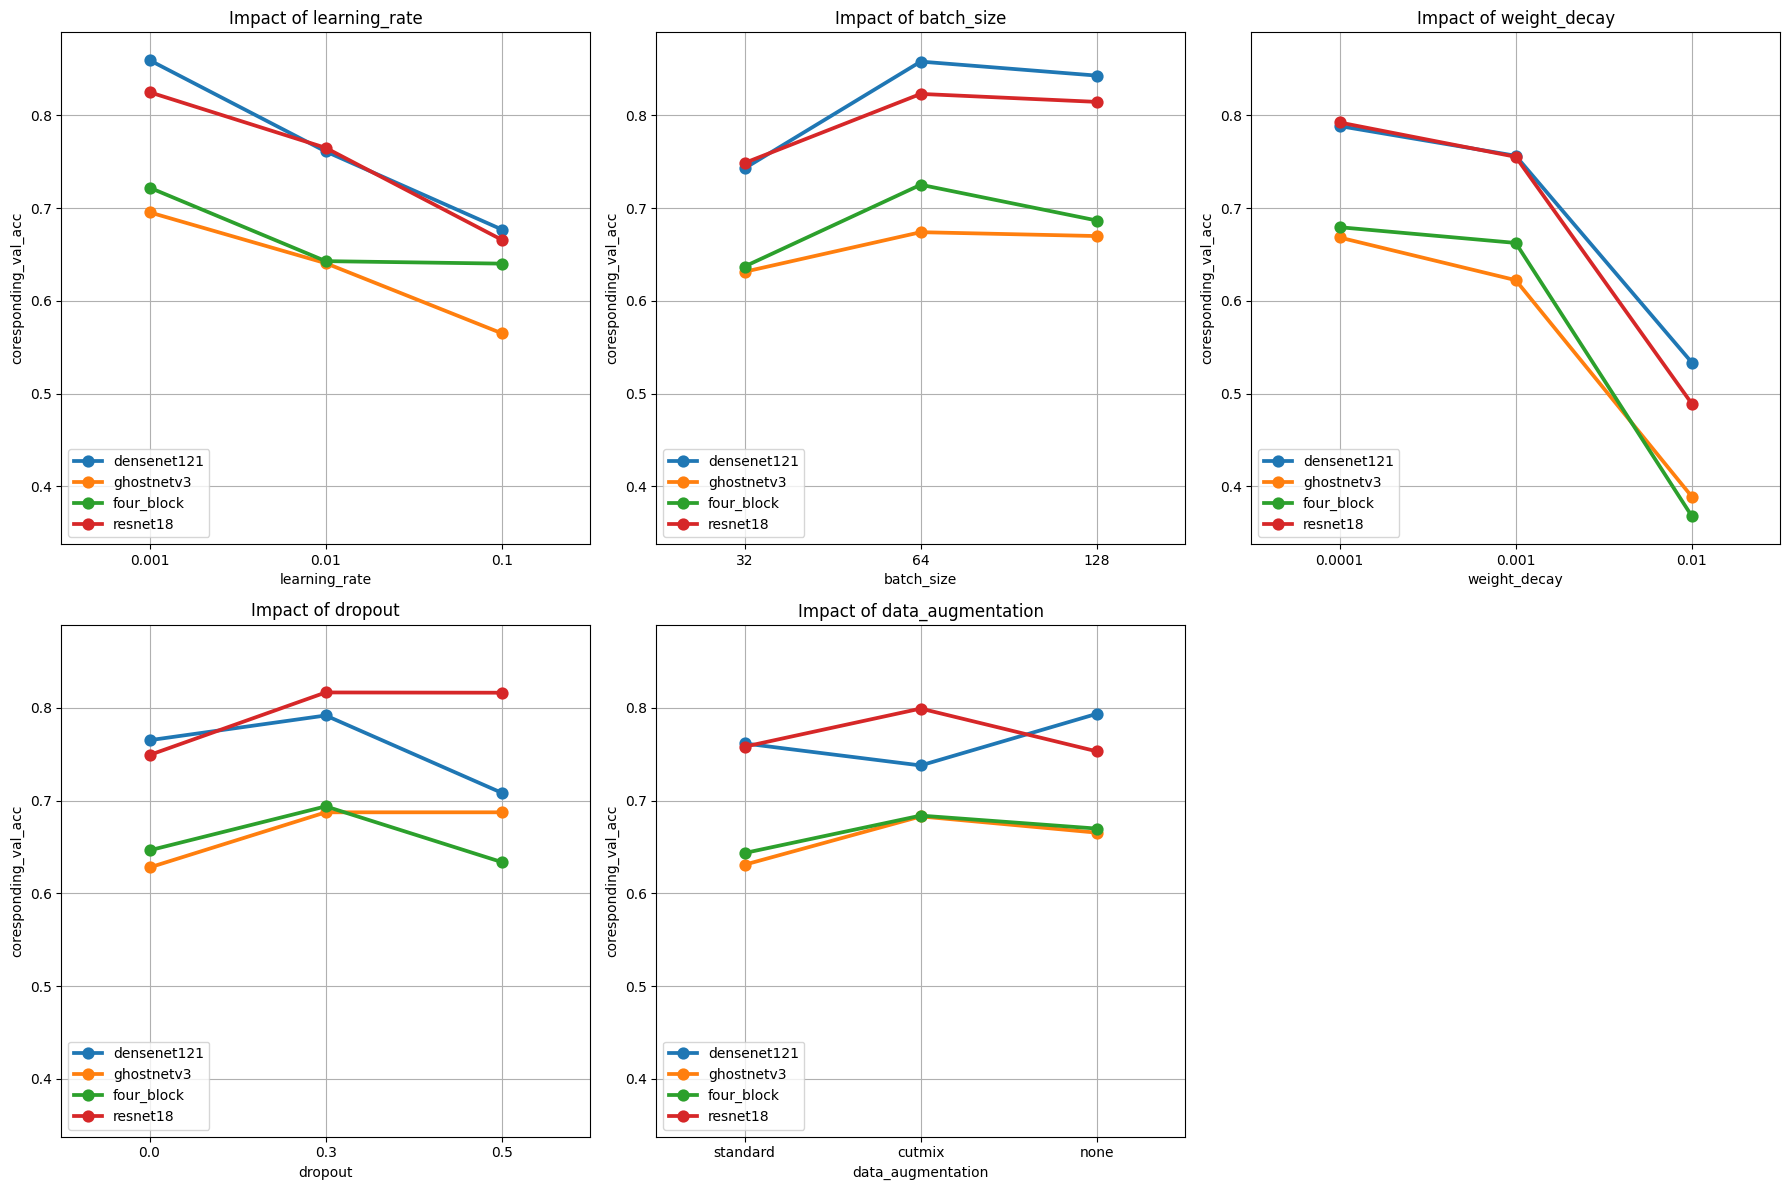

In [ ]:
hp_cols = ['learning_rate', 'batch_size', 'weight_decay', 'dropout', 'data_augmentation']
ymin = exp['coresponding_val_acc'].min()
ymax = exp['coresponding_val_acc'].max()
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, hp in enumerate(hp_cols):
    sns.pointplot(data=exp, x=hp, y='coresponding_val_acc', hue='model', ax=axes[i], markers='o', errorbar=None) #, capsize=.1)
    axes[i].set_title(f'Impact of {hp}')
    axes[i].grid(True)
    axes[i].set_ylim(ymin-0.03, ymax+0.03) 
    axes[i].legend(loc='lower left')
fig.delaxes(axes[-1])

plt.tight_layout()